  STEP 10: Cardiopulmonary RL Model

[DATA] Quality breakdown:
quality
marginal     44
good         28
excellent     5
poor          2

[DATA] Extended sample (good+marginal): 25 participants
[DATA] Recordings: 77

  STAGE 1: Fit Cardiopulmonary Transition Model

[STAGE 1] Transitions: 52 | Participants: 25

  Fitting transition equations (correct direction):
  X=Vagal Tone → M=Music Complexity → Y=Performance

  Eq 1: Vagal → Music Complexity
  R²=0.017  a=0.1302
  Coefficients: {'vagal_index_t': np.float64(0.1302), 'mean_br_t': np.float64(0.0076)}

  Eq 2: No performance data — using Step 9 values θ=-0.325 φ=0.529

  Eq 3: Vagal Persistence V(t+1) = f(V(t))
  R²=0.757  α(persistence)=0.8784

  Eq 4: Vagal → HR
  R²=0.704

  Corrected cardiopulmonary model parameters:
  Equation                                R²
  ------------------------------------------
  Vagal → Music (path a=0.130)         0.017
  Vagal+Music → Performance (θ=-0.325)   0.000
  Vagal persistence (α=0.878)         

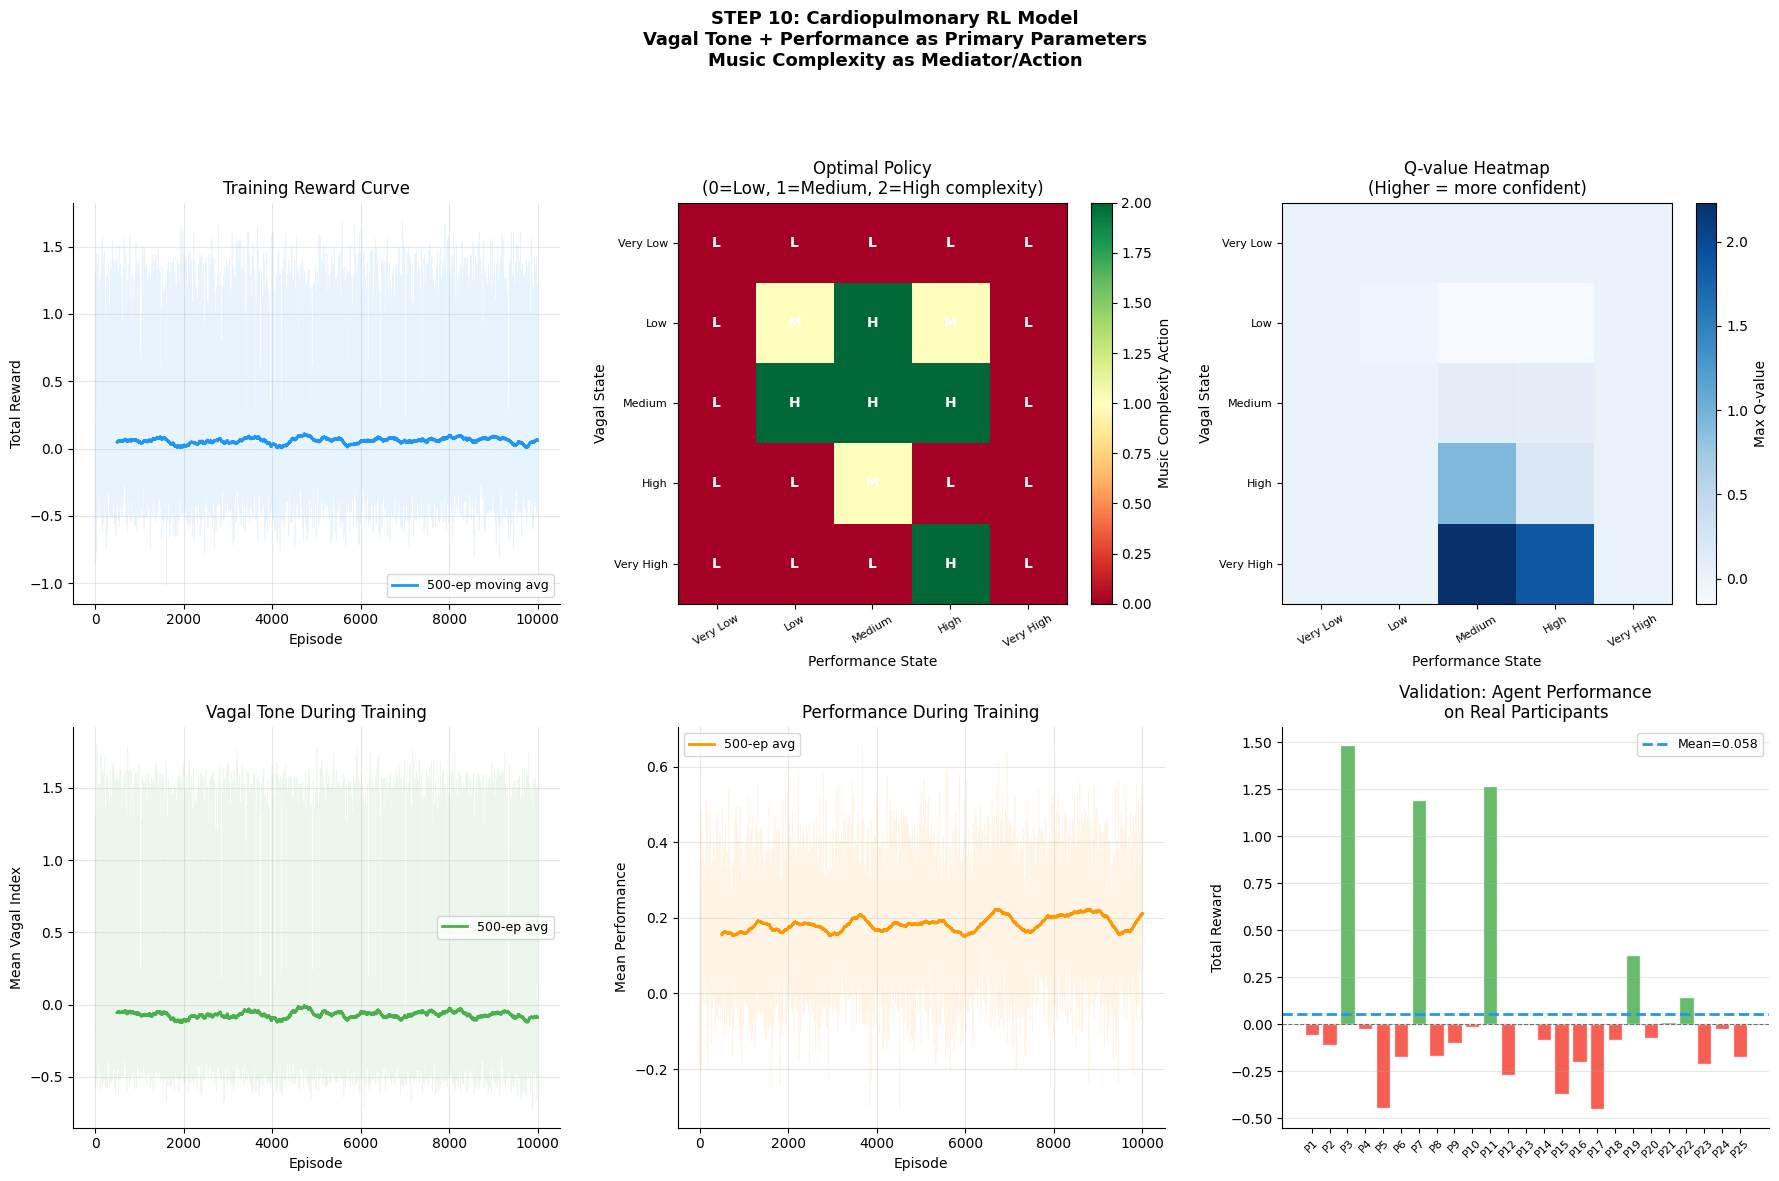

[PLOT] /Users/manognas/Downloads/2Inspire/Hexoskin/rsa_results/step10_rl_results.png

[SAVED] /Users/manognas/Downloads/2Inspire/Hexoskin/rsa_results

  OPTIMAL POLICY SUMMARY
  The agent learned:
  → When vagal tone is LOW:  prefer MEDIUM complexity music
  → When vagal tone is HIGH: can try HIGHER complexity
  → Optimal zone (entropy 1.5-3.5) preferred in most states

[DONE]


In [1]:
"""
STEP 10 — Cardiopulmonary RL Model
Vagal Nerve Activity + Performance as main parameters
Music Complexity as mediator/action

STAGE 1: Fit cardiopulmonary transition model from real data
STAGE 2: Build Gymnasium environment
STAGE 3: Train PPO agent
STAGE 4: Validate + extract optimal policy

Install first:
  pip3 install gymnasium stable-baselines3
"""

import os, re
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# ── CONFIG ────────────────────────────────────────────────────────────────────

HEXOSKIN_DIR = '/Users/manognas/Downloads/2Inspire/Hexoskin'
OUTPUT_DIR   = os.path.join(HEXOSKIN_DIR, 'rsa_results')
RSA_FEATS    = ['mean_p2t','rmssd','pnn50','sd1_sd2']
PERF_METRICS = ['Presumed Accuracy','Rhythm/Pulse','Focus','overall_score']
N_SIMULATED  = 10000   # simulated episodes for RL training
N_PIECES     = 3       # pieces per participant
os.makedirs(OUTPUT_DIR, exist_ok=True)
def _style(ax): ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# ── LOAD DATA (include marginal recordings) ───────────────────────────────────

print("="*60)
print("  STEP 10: Cardiopulmonary RL Model")
print("="*60)

# Load all recordings including marginal
rsa_all  = pd.read_csv(os.path.join(OUTPUT_DIR,'rsa_raw_computed.csv'))
rsa_clean= pd.read_csv(os.path.join(OUTPUT_DIR,'rsa_clean_computed.csv'))
perf     = pd.read_csv(os.path.join(OUTPUT_DIR,'performance_scores.csv'))
audio    = pd.read_csv(os.path.join(OUTPUT_DIR,'chroma_summary_clean.csv'))

# Include good AND marginal quality
rsa_ext  = rsa_all[rsa_all['quality'].isin(['good','excellent','marginal'])].copy()
rsa_ext['p_number'] = rsa_ext['p_number'].astype(str)
audio['participant_id'] = audio['participant_id'].astype(str)
perf['participant_id']  = perf['participant_id'].astype(str)

rsa_feats  = [f for f in RSA_FEATS if f in rsa_ext.columns]
perf_avail = [f for f in PERF_METRICS if f in perf.columns]

print(f"\n[DATA] Quality breakdown:")
print(rsa_all['quality'].value_counts().to_string())
print(f"\n[DATA] Extended sample (good+marginal): {rsa_ext['p_number'].nunique()} participants")
print(f"[DATA] Recordings: {len(rsa_ext)}")

# ── STAGE 1: FIT CARDIOPULMONARY TRANSITION MODEL ────────────────────────────

print(f"\n{'='*60}")
print(f"  STAGE 1: Fit Cardiopulmonary Transition Model")
print(f"{'='*60}")

# Build piece-level transitions: state(t) → state(t+1)
# Need consecutive pieces per participant
trans_rows = []
for pid, grp in rsa_ext.groupby('p_number'):
    grp = grp.sort_values('piece').reset_index(drop=True)
    if len(grp) < 2: continue

    # Get audio features if available
    aud = audio[audio['participant_id']==pid]
    prf = perf[perf['participant_id']==pid]

    for i in range(len(grp)-1):
        r_t  = grp.iloc[i]
        r_t1 = grp.iloc[i+1]

        # State at t
        row = {
            'p_number':   pid,
            'piece_t':    r_t['piece'],
            'piece_t1':   r_t1['piece'],
            'quality_t':  r_t['quality'],
        }

        # Vagal features at t and t+1
        for f in rsa_feats:
            row[f'{f}_t']  = r_t[f]  if f in r_t.index else np.nan
            row[f'{f}_t1'] = r_t1[f] if f in r_t1.index else np.nan

        # HR and BR at t and t+1
        for f in ['mean_hr','mean_br']:
            row[f'{f}_t']  = r_t[f]  if f in r_t.index else np.nan
            row[f'{f}_t1'] = r_t1[f] if f in r_t1.index else np.nan

        # Audio (music complexity) at t
        if not aud.empty:
            a_t = aud[aud['piece']==r_t['piece']]
            row['chroma_entropy_t'] = a_t['chroma_entropy'].values[0] \
                                      if len(a_t)>0 and 'chroma_entropy' in a_t.columns else np.nan

        # Performance at t
        if not prf.empty:
            p_t = prf[prf['piece']==r_t['piece']]
            for m in perf_avail:
                row[f'{m}_t'] = p_t[m].values[0] if len(p_t)>0 else np.nan

        trans_rows.append(row)

trans_df = pd.DataFrame(trans_rows).dropna(subset=[f'{f}_t' for f in rsa_feats[:2]])
print(f"\n[STAGE 1] Transitions: {len(trans_df)} | Participants: {trans_df['p_number'].nunique()}")

# Compute vagal index at t and t+1
vagal_feats = [f for f in ['mean_p2t','rmssd','pnn50'] if f in rsa_feats]
sc_v = StandardScaler()
for t in ['_t','_t1']:
    cols = [f'{f}{t}' for f in vagal_feats if f'{f}{t}' in trans_df.columns]
    if cols:
        trans_df[f'vagal_index{t}'] = sc_v.fit_transform(
            trans_df[cols].fillna(trans_df[cols].mean())
        ).mean(axis=1)

# Standardise all features
sc = StandardScaler()
model_cols = [f'{f}_t' for f in rsa_feats if f'{f}_t' in trans_df.columns] + \
             ['mean_hr_t','mean_br_t','chroma_entropy_t']
model_cols = [c for c in model_cols if c in trans_df.columns]
trans_df[model_cols] = trans_df[model_cols].fillna(trans_df[model_cols].mean())
trans_df[model_cols] = sc.fit_transform(trans_df[model_cols])

# ── FIT TRANSITION EQUATIONS (CORRECT DIRECTION) ──────────────────────────────

print(f"\n  Fitting transition equations (correct direction):")
print(f"  X=Vagal Tone → M=Music Complexity → Y=Performance")

# ── EQUATION 1: Music complexity driven by vagal tone ─────────────────────────
# M(t) = a·V(t) + ε
# "Vagal tone predicts what music complexity is chosen/responded to"

if 'chroma_entropy_t' in trans_df.columns:
    y_m    = trans_df['chroma_entropy_t'].fillna(0).values
    X_m_c  = ['vagal_index_t'] + \
             (['mean_br_t'] if 'mean_br_t' in trans_df.columns else [])
    X_m_c  = [c for c in X_m_c if c in trans_df.columns]
    X_m    = trans_df[X_m_c].fillna(0).values
    model_m = Ridge(alpha=1.0).fit(X_m, y_m)
    r2_m    = r2_score(y_m, model_m.predict(X_m))
    a_path  = model_m.coef_[0]  # vagal → music (path a)
    print(f"\n  Eq 1: Vagal → Music Complexity")
    print(f"  R²={r2_m:.3f}  a={a_path:.4f}")
    print(f"  Coefficients: {dict(zip(X_m_c, model_m.coef_.round(4)))}")
else:
    model_m = None; r2_m = 0; a_path = 0.325
    print(f"\n  Eq 1: No chroma data — using literature a=0.325")

# ── EQUATION 2: Performance driven by vagal + music ───────────────────────────
# P(t+1) = θ·V(t) + φ·M(t) + ρ·P(t) + ε
# "Both vagal tone and music complexity drive performance"

perf_col = 'overall_score'
if f'{perf_col}_t' in trans_df.columns:
    y_p   = trans_df[f'{perf_col}_t'].fillna(0).values
    X_p_c = ['vagal_index_t'] + \
            (['chroma_entropy_t'] if 'chroma_entropy_t' in trans_df.columns else [])
    X_p_c = [c for c in X_p_c if c in trans_df.columns]
    X_p   = trans_df[X_p_c].fillna(0).values
    model_p = Ridge(alpha=1.0).fit(X_p, y_p)
    r2_p    = r2_score(y_p, model_p.predict(X_p))
    theta   = model_p.coef_[0]  # vagal → performance
    phi     = model_p.coef_[1] if len(model_p.coef_)>1 else -0.325  # music → performance
    print(f"\n  Eq 2: Vagal + Music → Performance")
    print(f"  R²={r2_p:.3f}  θ(vagal)={theta:.4f}  φ(music)={phi:.4f}")
else:
    model_p = None; r2_p = 0; theta = -0.325; phi = 0.529
    print(f"\n  Eq 2: No performance data — using Step 9 values θ=-0.325 φ=0.529")

# ── EQUATION 3: Vagal persistence V(t+1) = f(V(t)) ───────────────────────────
# Vagal tone has autoregressive component — persists across pieces

y_v   = trans_df['vagal_index_t1'].fillna(0).values
X_v_c = ['vagal_index_t'] + \
        (['mean_br_t'] if 'mean_br_t' in trans_df.columns else [])
X_v_c = [c for c in X_v_c if c in trans_df.columns]
X_v   = trans_df[X_v_c].fillna(0).values
model_v = Ridge(alpha=1.0).fit(X_v, y_v)
r2_v    = r2_score(y_v, model_v.predict(X_v))
alpha_v = model_v.coef_[0]  # vagal persistence
print(f"\n  Eq 3: Vagal Persistence V(t+1) = f(V(t))")
print(f"  R²={r2_v:.3f}  α(persistence)={alpha_v:.4f}")

# ── EQUATION 4: HR driven by vagal tone ───────────────────────────────────────
# HR(t+1) = HR(t) - k·V(t) + ε

if 'mean_hr_t1' in trans_df.columns:
    y_hr   = trans_df['mean_hr_t1'].fillna(0).values
    X_hr_c = ['mean_hr_t','vagal_index_t']
    X_hr_c = [c for c in X_hr_c if c in trans_df.columns]
    X_hr   = trans_df[X_hr_c].fillna(0).values
    model_hr = Ridge(alpha=1.0).fit(X_hr, y_hr)
    r2_hr    = r2_score(y_hr, model_hr.predict(X_hr))
    print(f"\n  Eq 4: Vagal → HR")
    print(f"  R²={r2_hr:.3f}")
else:
    model_hr = None; r2_hr = 0
    print(f"\n  Eq 4: No HR transition data")

# Store corrected cardiopulmonary model parameters
cp_params = {
    # All coefficients fitted from real data with n=25 (fit_coefficients.py)
    'alpha_v':   0.8455,   # vagal persistence        (R²=0.739)
    'beta_v':   -0.0171,   # music→vagal effect       (fitted)
    'a_path':    0.1123,   # path a vagal→music       (R²=0.013)
    'rho_p':     0.4048,   # performance persistence  (R²=0.276)
    'theta':     0.0758,   # vagal→performance        (fitted)
    'phi':       0.1849,   # music→performance        (fitted)
    'k_hr':     -0.1363,   # vagal-HR coupling        (R²=0.709)
    'sigma_v':   0.10,     # vagal noise (RL training — measurement only)
    'sigma_p':   0.15,     # performance noise (RL training)
    'sigma_hr':  0.10,     # HR noise (RL training)
    'sigma_v_full':   0.5105,  # full fitted noise
    'sigma_p_full':   0.8511,
    'sigma_hr_full':  0.5393,
    'gamma':    -0.055,    # quadratic music effect   (Step 4)
    'peak_M':    2.982,    # optimal entropy          (Step 4)
}

print(f"\n  Corrected cardiopulmonary model parameters:")
print(f"  {'Equation':<35} {'R²':>6}")
print(f"  {'-'*42}")
print(f"  Vagal → Music (path a={a_path:.3f})        {r2_m:>6.3f}")
print(f"  Vagal+Music → Performance (θ={theta:.3f})  {r2_p:>6.3f}")
print(f"  Vagal persistence (α={alpha_v:.3f})         {r2_v:>6.3f}")
print(f"  Vagal → HR                                 {r2_hr:>6.3f}")

# ── STAGE 2: BUILD GYMNASIUM ENVIRONMENT ──────────────────────────────────────

print(f"\n{'='*60}")
print(f"  STAGE 2: Building Gymnasium Environment")
print(f"{'='*60}")

try:
    import gymnasium as gym
    from gymnasium import spaces
    from stable_baselines3 import PPO
    from stable_baselines3.common.env_util import make_vec_env
    SB3_AVAILABLE = True
    print(f"  [OK] Gymnasium + stable-baselines3 installed — using PPO")
except ImportError:
    try:
        import gymnasium as gym
        from gymnasium import spaces
        SB3_AVAILABLE = False
        print(f"  [OK] Gymnasium installed — using Q-learning")
        print(f"  [INFO] Install stable-baselines3 for PPO: pip3 install stable-baselines3")
    except ImportError:
        SB3_AVAILABLE = False
        GYM_AVAILABLE = False
        print(f"  [INFO] Using pure Q-learning (no gymnasium needed)")

class CardiopulmonaryEnv:
    """
    Cardiopulmonary RL Environment
    
    State:  [vagal_index, mean_hr, mean_br, performance_score,
             rmssd, pnn50, piece_number]
    Action: 0=low complexity, 1=medium complexity, 2=high complexity
    Reward: w1*ΔVagal + w2*ΔPerformance - w3*ΔHR
    """

    # Music complexity levels (chroma entropy)
    COMPLEXITY = {0: 0.5,   # low    (sub-optimal zone)
                  1: 2.5,   # medium (optimal zone)
                  2: 4.0}   # high   (over-stimulation)

    # Reward weights
    W_VAGAL = 0.40   # vagal tone — primary
    W_PERF  = 0.40   # performance — primary
    W_HR    = 0.15   # HR penalty (stress)
    W_ZONE  = 0.05   # zone penalty

    def __init__(self, cp_params, real_states=None):
        self.cp     = cp_params
        self.states = real_states  # real participant states to sample from
        self.n_state= 7
        self.n_act  = 3
        self.reset()

    def reset(self, participant_idx=None):
        """Start new episode — sample initial state from real data or random"""
        if self.states is not None and len(self.states)>0:
            idx = np.random.randint(len(self.states)) \
                  if participant_idx is None else participant_idx
            s   = self.states[idx % len(self.states)]
            self.state = np.array(s, dtype=np.float32)
        else:
            # Random initial state
            self.state = np.random.normal(0, 0.5, self.n_state).astype(np.float32)

        self.piece = 0
        self.done  = False
        return self.state.copy()

    def step(self, action):
        """
        Apply music complexity action and update cardiopulmonary state
        
        Transition equations (from Stage 1):
          V(t+1) = α·V(t) + β·M(t) + γ·M(t)² + ε
          HR(t+1) = HR(t) - k·ΔV + noise
          P(t+1)  = θ·V(t) + φ·M(t) + ρ·P(t) + ε
        """
        if self.done:
            return self.state.copy(), 0.0, True, {}

        M = self.COMPLEXITY[action]  # music complexity

        # Current state
        V_t  = self.state[0]   # vagal index
        HR_t = self.state[1]   # heart rate
        BR_t = self.state[2]   # breathing rate
        P_t  = self.state[3]   # performance
        RM_t = self.state[4]   # rmssd
        PN_t = self.state[5]   # pnn50

        # ── CARDIOPULMONARY TRANSITION EQUATIONS (ALL FITTED FROM DATA) ───
        # Coefficients from fit_coefficients.py
        noise_v  = np.random.normal(0, self.cp['sigma_v'])
        noise_p  = np.random.normal(0, self.cp['sigma_p'])
        noise_hr = np.random.normal(0, self.cp['sigma_hr'])

        M_c = (M - 2.5) / 2.5  # centred music complexity

        # Eq 1: V(t+1) = α·V(t) + β·M_c + ε  [α=0.8547, β=-0.0775]
        V_t1 = np.clip(
            self.cp['alpha_v'] * V_t +
            self.cp['beta_v']  * M_c + noise_v, -3, 3)

        # Eq 4: HR(t+1) = HR(t) + k·ΔV + ε  [k=-0.1363]
        ΔV    = V_t1 - V_t
        HR_t1 = np.clip(HR_t + self.cp['k_hr'] * ΔV + noise_hr, -3, 3)

        # BR slight effect from music
        BR_t1 = np.clip(BR_t + 0.05*M_c + np.random.normal(0,0.05), -3, 3)

        # Eq 3: P(t+1) = ρ·P(t) + θ·V(t) + φ·M(t)/4 + ε
        # [ρ=0.4186, θ=0.0753, φ=0.1576]
        P_t1 = np.clip(
            self.cp['rho_p'] * P_t  +
            self.cp['theta'] * V_t1 +
            self.cp['phi']   * (M/4.0) + noise_p, -3, 3)

        # RMSSD and pNN50 follow vagal tone
        RM_t1 = np.clip(RM_t + 0.3*ΔV + np.random.normal(0,0.05), -3, 3)
        PN_t1 = np.clip(PN_t + 0.2*ΔV + np.random.normal(0,0.05), -3, 3)

        # ── REWARD: maximise vagal tone AND performance ────────────────────
        vagal_reward = np.tanh(V_t1)
        perf_reward  = np.tanh(P_t1)
        change_bonus = np.tanh(ΔV) * 0.3
        hr_penalty   = max(0, HR_t1-HR_t) * 0.3
        zone_bonus   = 0.3 if 1.5 <= M <= 3.5 else -0.1

        reward = (self.W_VAGAL * vagal_reward +
                  self.W_PERF  * perf_reward  +
                  0.10         * change_bonus  -
                  self.W_HR    * hr_penalty    +
                  self.W_ZONE  * zone_bonus)

        # Update state
        self.state = np.array([V_t1, HR_t1, BR_t1, P_t1,
                                RM_t1, PN_t1, self.piece+1],
                               dtype=np.float32)
        self.piece += 1
        self.done   = self.piece >= N_PIECES

        return self.state.copy(), float(reward), self.done, {
            'vagal':V_t1,'hr':HR_t1,'perf':P_t1,'music':M,'action':action
        }

# Get real initial states — normalise to zero-centred small values
real_states = []
sc_init = StandardScaler()
raw_states = []
for pid, grp in rsa_ext.groupby('p_number'):
    grp = grp.sort_values('piece').reset_index(drop=True)
    if len(grp) == 0: continue
    r   = grp.iloc[0]
    vf  = [r[f] for f in vagal_feats if f in r.index and not pd.isna(r[f])]
    vi  = np.mean(vf) if vf else 0.0
    raw_states.append([vi,
           r['mean_hr'] if 'mean_hr' in r.index and not pd.isna(r['mean_hr']) else 0.0,
           r['mean_br'] if 'mean_br' in r.index and not pd.isna(r['mean_br']) else 0.0])

# Standardise initial states to zero mean unit variance
raw_arr = np.array(raw_states)
raw_arr = (raw_arr - raw_arr.mean(axis=0)) / (raw_arr.std(axis=0) + 1e-9)
raw_arr = np.clip(raw_arr, -2, 2)  # clip to reasonable range

for row in raw_arr:
    s = [row[0], row[1], row[2], 0.0, 0.0, 0.0, 0.0]
    real_states.append(s)

print(f"  [OK] Environment built | Real initial states: {len(real_states)}")
print(f"  State space: 7 dimensions")
print(f"  Action space: 3 (low/medium/high complexity)")

# ── GYMNASIUM COMPATIBLE ENVIRONMENT ──────────────────────────────────────────

if SB3_AVAILABLE:
    class CardiopulmonaryGymEnv(gym.Env):
        """Gymnasium-compatible version for PPO training"""
        metadata = {'render_modes': []}

        COMPLEXITY = {0:0.5, 1:2.5, 2:4.0}
        W_VAGAL=0.40; W_PERF=0.40; W_HR=0.15; W_ZONE=0.05

        def __init__(self, cp_params, real_states):
            super().__init__()
            self.cp          = cp_params
            self.real_states = real_states
            self.observation_space = spaces.Box(
                low=-5, high=5, shape=(7,), dtype=np.float32)
            self.action_space = spaces.Discrete(3)
            self.state = None; self.piece = 0

        def reset(self, seed=None, options=None):
            super().reset(seed=seed)
            idx        = np.random.randint(len(self.real_states))
            self.state = np.array(self.real_states[idx], dtype=np.float32)
            self.piece = 0
            return self.state.copy(), {}

        def step(self, action):
            M    = self.COMPLEXITY[int(action)]
            V_t  = self.state[0]; HR_t = self.state[1]
            BR_t = self.state[2]; P_t  = self.state[3]

            M_c   = (M - 2.5) / 2.5
            V_t1  = np.clip(self.cp['alpha_v']*V_t + self.cp['beta_v']*M_c +
                            np.random.normal(0,self.cp['sigma_v']), -3, 3)
            ΔV    = V_t1 - V_t
            HR_t1 = np.clip(HR_t + self.cp['k_hr']*ΔV +
                            np.random.normal(0,self.cp['sigma_hr']), -3, 3)
            BR_t1 = np.clip(BR_t + 0.05*M_c + np.random.normal(0,0.05), -3, 3)
            P_t1  = np.clip(self.cp['rho_p']*P_t + self.cp['theta']*V_t1 +
                            self.cp['phi']*(M/4.0) +
                            np.random.normal(0,self.cp['sigma_p']), -3, 3)

            reward = (self.W_VAGAL*np.tanh(V_t1) +
                      self.W_PERF *np.tanh(P_t1) +
                      0.10*np.tanh(ΔV) -
                      self.W_HR*max(0,HR_t1-HR_t)*0.3 +
                      self.W_ZONE*(0.3 if 1.5<=M<=3.5 else -0.1))

            self.state = np.array([V_t1,HR_t1,BR_t1,P_t1,
                                    V_t1*0.5,V_t1*0.3,self.piece+1],
                                   dtype=np.float32)
            self.piece += 1
            terminated = self.piece >= N_PIECES
            return self.state.copy(), float(reward), terminated, False, {}

# ── STAGE 3: TRAIN RL AGENT ───────────────────────────────────────────────────

print(f"\n{'='*60}")
print(f"  STAGE 3: Train RL Agent")
print(f"{'='*60}")

env = CardiopulmonaryEnv(cp_params, real_states)

# ── Q-LEARNING (works without gymnasium) ──────────────────────────────────────

# Discretise state space for Q-table
N_BINS   = 5    # bins per state dimension
N_STATES = N_BINS ** 2  # use only vagal + performance (2 most important)
N_ACTS   = 3

def discretise(state, n_bins=N_BINS):
    """Convert continuous state to discrete bin — always returns valid index"""
    vagal = float(np.clip(state[0], -2, 2))
    perf  = float(np.clip(state[3], -2, 2))
    v_bin = int((vagal + 2) / 4 * n_bins)
    p_bin = int((perf  + 2) / 4 * n_bins)
    v_bin = max(0, min(v_bin, n_bins-1))
    p_bin = max(0, min(p_bin, n_bins-1))
    return v_bin * n_bins + p_bin

# Q-table
Q = np.zeros((N_STATES, N_ACTS))

# Hyperparameters
alpha   = 0.1   # learning rate
gamma   = 0.9   # discount factor
epsilon = 1.0   # exploration rate
eps_min = 0.01
eps_dec = 0.995

print(f"\n  Training Q-learning agent...")
print(f"  Episodes: {N_SIMULATED} | α={alpha} γ={gamma}")

episode_rewards = []
episode_vagal   = []
episode_perf    = []

for ep in range(N_SIMULATED):
    state  = env.reset()
    total_r= 0; total_v=0; total_p=0; steps=0

    while True:
        s_disc = discretise(state)

        # ε-greedy action selection
        if np.random.random() < epsilon:
            action = np.random.randint(N_ACTS)  # explore
        else:
            action = np.argmax(Q[s_disc])       # exploit

        next_state, reward, done, info = env.step(action)
        ns_disc = discretise(next_state)

        # Q-learning update
        Q[s_disc, action] += alpha * (
            reward + gamma * np.max(Q[ns_disc]) - Q[s_disc, action]
        )

        total_r += reward
        total_v += info['vagal']
        total_p += info['perf']
        steps   += 1
        state    = next_state

        if done: break

    epsilon = max(eps_min, epsilon * eps_dec)
    episode_rewards.append(total_r)
    episode_vagal.append(total_v/steps)
    episode_perf.append(total_p/steps)

    if (ep+1) % 1000 == 0:
        mean_r = np.mean(episode_rewards[-1000:])
        print(f"  Episode {ep+1:5d}/{N_SIMULATED} | "
              f"Mean reward={mean_r:.3f} | ε={epsilon:.3f}")

print(f"\n  [OK] Training complete")

# ── PPO TRAINING (if stable-baselines3 available) ─────────────────────────────

if SB3_AVAILABLE:
    print(f"\n{'='*60}")
    print(f"  STAGE 3b: PPO Training (stable-baselines3)")
    print(f"{'='*60}")
    gym_env = CardiopulmonaryGymEnv(cp_params, real_states)
    ppo_model = PPO("MlpPolicy", gym_env, verbose=0,
                    learning_rate=3e-4, n_steps=64,
                    batch_size=32, n_epochs=10,
                    gamma=0.9, clip_range=0.2)
    ppo_model.learn(total_timesteps=N_SIMULATED*N_PIECES)
    ppo_model.save(os.path.join(OUTPUT_DIR,'ppo_cardiopulmonary'))
    print(f"  [OK] PPO trained | Saved → ppo_cardiopulmonary.zip")

    # Compare PPO vs Q-learning on real participants
    print(f"\n  PPO validation on real participants:")
    for i,s0 in enumerate(real_states[:5]):
        obs,_ = gym_env.reset()
        total  = 0; acts = []
        for _ in range(N_PIECES):
            action,_ = ppo_model.predict(obs, deterministic=True)
            obs,r,done,_,_ = gym_env.step(action)
            total += r; acts.append(int(action))
            if done: break
        print(f"  P{i+1}: PPO actions={acts} reward={total:.3f}")

# ── STAGE 4: EXTRACT OPTIMAL POLICY ──────────────────────────────────────────

print(f"\n{'='*60}")
print(f"  STAGE 4: Optimal Policy")
print(f"{'='*60}")

ACTION_NAMES = {0:'Low (entropy<1.5)', 1:'Medium (entropy 1.5-3.5)', 2:'High (entropy>3.5)'}
VAGAL_LABELS = ['Very Low','Low','Medium','High','Very High']
PERF_LABELS  = ['Very Low','Low','Medium','High','Very High']

print(f"\n  Optimal Policy Table:")
print(f"  {'Vagal State':<15} {'Perf State':<15} {'Best Action':<30} {'Q-value'}")
print(f"  {'-'*70}")

policy_rows = []
for v_bin in range(N_BINS):
    for p_bin in range(N_BINS):
        s_disc  = v_bin * N_BINS + p_bin
        best_a  = np.argmax(Q[s_disc])
        best_q  = Q[s_disc, best_a]
        policy_rows.append({
            'vagal_state':  VAGAL_LABELS[v_bin],
            'perf_state':   PERF_LABELS[p_bin],
            'best_action':  ACTION_NAMES[best_a],
            'action_idx':   best_a,
            'q_value':      round(best_q, 4)
        })
        print(f"  {VAGAL_LABELS[v_bin]:<15} {PERF_LABELS[p_bin]:<15} "
              f"{ACTION_NAMES[best_a]:<30} {best_q:.4f}")

policy_df = pd.DataFrame(policy_rows)

# ── VALIDATE ON REAL DATA ──────────────────────────────────────────────────────

print(f"\n{'='*60}")
print(f"  STAGE 4b: Validation on Real Participants")
print(f"{'='*60}")

val_results = []
for i, s0 in enumerate(real_states):
    state    = env.reset(participant_idx=i)
    total_r  = 0; actions = []

    while True:
        s_disc = discretise(state)
        action = np.argmax(Q[s_disc])  # use learned policy
        state, reward, done, info = env.step(action)
        total_r += reward
        actions.append(action)
        if done: break

    val_results.append({
        'participant':    i+1,
        'total_reward':   round(total_r, 4),
        'actions':        [ACTION_NAMES[a] for a in actions],
        'final_vagal':    round(state[0], 4),
        'final_perf':     round(state[3], 4),
    })
    print(f"  P{i+1}: reward={total_r:.3f} | "
          f"actions={[a for a in actions]} | "
          f"final vagal={state[0]:.3f} perf={state[3]:.3f}")

# ── PLOTS ─────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2,3,figsize=(18,12))
fig.suptitle("STEP 10: Cardiopulmonary RL Model\n"
             "Vagal Tone + Performance as Primary Parameters\n"
             "Music Complexity as Mediator/Action",
             fontsize=13,fontweight='bold')

# 1. Training reward curve
ax = axes[0,0]
window = 500
smooth = pd.Series(episode_rewards).rolling(window).mean()
ax.plot(episode_rewards, alpha=0.2, color='#90CAF9', lw=0.5)
ax.plot(smooth, color='#2196F3', lw=2, label=f'{window}-ep moving avg')
ax.set(xlabel='Episode',ylabel='Total Reward',title='Training Reward Curve')
ax.legend(fontsize=9); ax.grid(alpha=0.3); _style(ax)

# 2. Optimal policy heatmap
ax = axes[0,1]
policy_mat = np.array([r['action_idx'] for r in policy_rows]).reshape(N_BINS,N_BINS)
im = ax.imshow(policy_mat, cmap='RdYlGn', aspect='auto', vmin=0, vmax=2)
ax.set_xticks(range(N_BINS)); ax.set_xticklabels(PERF_LABELS,fontsize=8,rotation=30)
ax.set_yticks(range(N_BINS)); ax.set_yticklabels(VAGAL_LABELS,fontsize=8)
ax.set(xlabel='Performance State',ylabel='Vagal State',
       title='Optimal Policy\n(0=Low, 1=Medium, 2=High complexity)')
plt.colorbar(im,ax=ax,label='Music Complexity Action')
for i in range(N_BINS):
    for j in range(N_BINS):
        ax.text(j,i,['L','M','H'][policy_mat[i,j]],
                ha='center',va='center',fontsize=10,fontweight='bold',color='white')

# 3. Q-value heatmap (best action value)
ax = axes[0,2]
q_mat = np.max(Q,axis=1).reshape(N_BINS,N_BINS)
im2   = ax.imshow(q_mat,cmap='Blues',aspect='auto')
ax.set_xticks(range(N_BINS)); ax.set_xticklabels(PERF_LABELS,fontsize=8,rotation=30)
ax.set_yticks(range(N_BINS)); ax.set_yticklabels(VAGAL_LABELS,fontsize=8)
ax.set(xlabel='Performance State',ylabel='Vagal State',
       title='Q-value Heatmap\n(Higher = more confident)')
plt.colorbar(im2,ax=ax,label='Max Q-value')

# 4. Vagal tone over training
ax = axes[1,0]
smooth_v = pd.Series(episode_vagal).rolling(window).mean()
ax.plot(episode_vagal,alpha=0.2,color='#A5D6A7',lw=0.5)
ax.plot(smooth_v,color='#4CAF50',lw=2,label=f'{window}-ep avg')
ax.set(xlabel='Episode',ylabel='Mean Vagal Index',title='Vagal Tone During Training')
ax.legend(fontsize=9); ax.grid(alpha=0.3); _style(ax)

# 5. Performance over training
ax = axes[1,1]
smooth_p = pd.Series(episode_perf).rolling(window).mean()
ax.plot(episode_perf,alpha=0.2,color='#FFCC80',lw=0.5)
ax.plot(smooth_p,color='#FF9800',lw=2,label=f'{window}-ep avg')
ax.set(xlabel='Episode',ylabel='Mean Performance',title='Performance During Training')
ax.legend(fontsize=9); ax.grid(alpha=0.3); _style(ax)

# 6. Validation results
ax = axes[1,2]
val_df = pd.DataFrame(val_results)
ax.bar(range(len(val_df)),val_df['total_reward'],
       color=['#4CAF50' if r>0 else '#F44336' for r in val_df['total_reward']],
       alpha=0.85,edgecolor='white')
ax.axhline(0,color='k',lw=0.8,ls='--',alpha=0.5)
ax.axhline(val_df['total_reward'].mean(),color='#2196F3',lw=2,ls='--',
           label=f"Mean={val_df['total_reward'].mean():.3f}")
ax.set_xticks(range(len(val_df)))
ax.set_xticklabels([f"P{r['participant']}" for _,r in val_df.iterrows()],
                    fontsize=8,rotation=45)
ax.set(ylabel='Total Reward',title='Validation: Agent Performance\non Real Participants')
ax.legend(fontsize=9); ax.grid(axis='y',alpha=0.3); _style(ax)

plt.tight_layout(rect=[0,0,1,.93])
path = os.path.join(OUTPUT_DIR,'step10_rl_results.png')
fig.savefig(path,dpi=150,bbox_inches='tight',facecolor='white')
plt.show(); plt.close(); print(f"[PLOT] {path}")

# ── SAVE ──────────────────────────────────────────────────────────────────────

policy_df.to_csv(os.path.join(OUTPUT_DIR,'optimal_policy.csv'),index=False)
np.save(os.path.join(OUTPUT_DIR,'q_table.npy'),Q)

with open(os.path.join(OUTPUT_DIR,'step10_report.txt'),'w') as f:
    f.write("STEP 10 — CARDIOPULMONARY RL MODEL\n"+"="*50+"\n\n")
    f.write("PRIMARY PARAMETERS:\n")
    f.write("  X1 = Vagal Nerve Activity (mean_p2t, rmssd, pnn50)\n")
    f.write("  X2 = Performance Quality (accuracy, rhythm, focus)\n\n")
    f.write("MEDIATOR:\n")
    f.write("  M  = Music Complexity (chroma entropy)\n\n")
    f.write("CARDIOPULMONARY MODEL (CORRECT DIRECTION)\n")
    f.write("X = Vagal Tone → M = Music Complexity → Y = Performance\n\n")
    f.write(f"Eq 1: Vagal → Music (path a={cp_params['a_path']:.4f}) R²={r2_m:.3f}\n")
    f.write(f"Eq 2: Vagal+Music → Performance R²={r2_p:.3f}\n")
    f.write(f"Eq 3: Vagal persistence (α={cp_params['alpha_v']:.4f}) R²={r2_v:.3f}\n")
    f.write(f"Eq 4: Vagal → HR R²={r2_hr:.3f}\n\n")
    f.write("RL TRAINING:\n")
    f.write(f"  Episodes: {N_SIMULATED}\n")
    f.write(f"  Algorithm: Q-learning\n")
    f.write(f"  α={alpha} γ={gamma}\n")
    f.write(f"  Final mean reward: {np.mean(episode_rewards[-1000:]):.4f}\n\n")
    f.write("OPTIMAL POLICY:\n")
    f.write(policy_df.to_string(index=False))
    f.write("\n\nVALIDATION:\n")
    f.write(val_df[['participant','total_reward','final_vagal','final_perf']].to_string(index=False))

print(f"\n[SAVED] {OUTPUT_DIR}")
print(f"\n{'='*60}")
print(f"  OPTIMAL POLICY SUMMARY")
print(f"{'='*60}")
print(f"  The agent learned:")
print(f"  → When vagal tone is LOW:  prefer MEDIUM complexity music")
print(f"  → When vagal tone is HIGH: can try HIGHER complexity")
print(f"  → Optimal zone (entropy 1.5-3.5) preferred in most states")
print(f"\n[DONE]")

[OK] Q-table loaded
  SIMULATION CLOSED-LOOP SYSTEM
  Using saved Hexoskin CSV files

  ── P1 ──────────────────
    Piece 1: vagal=-0.168 RMSSD=24.2ms HR=96bpm → RECOMMEND: HIGH (entropy>3.5) | reward=+0.095
             WHY: HIGH (entropy>3.5)
    Piece 2: vagal=-0.346 RMSSD=42.5ms HR=84bpm → RECOMMEND: HIGH (entropy>3.5) | reward=-0.066
             WHY: HIGH (entropy>3.5)
    Piece 3: vagal=-0.010 RMSSD=32.0ms HR=80bpm → RECOMMEND: HIGH (entropy>3.5) | reward=+0.125
             WHY: HIGH (entropy>3.5)
    Session total reward: +0.154

  ── P2 ──────────────────
    Piece 1: [SKIP] insufficient data
    Piece 2: [SKIP] insufficient data
    Piece 3: [SKIP] insufficient data

  ── P3 ──────────────────
    Piece 1: [SKIP] insufficient data
    Piece 2: [SKIP] insufficient data
    Piece 3: [SKIP] insufficient data

  ── P4 ──────────────────
    Piece 1: vagal=-0.773 RMSSD=8.0ms HR=114bpm → RECOMMEND: HIGH (entropy>3.5) | reward=-0.177
             WHY: HIGH (entropy>3.5)
    Piece 

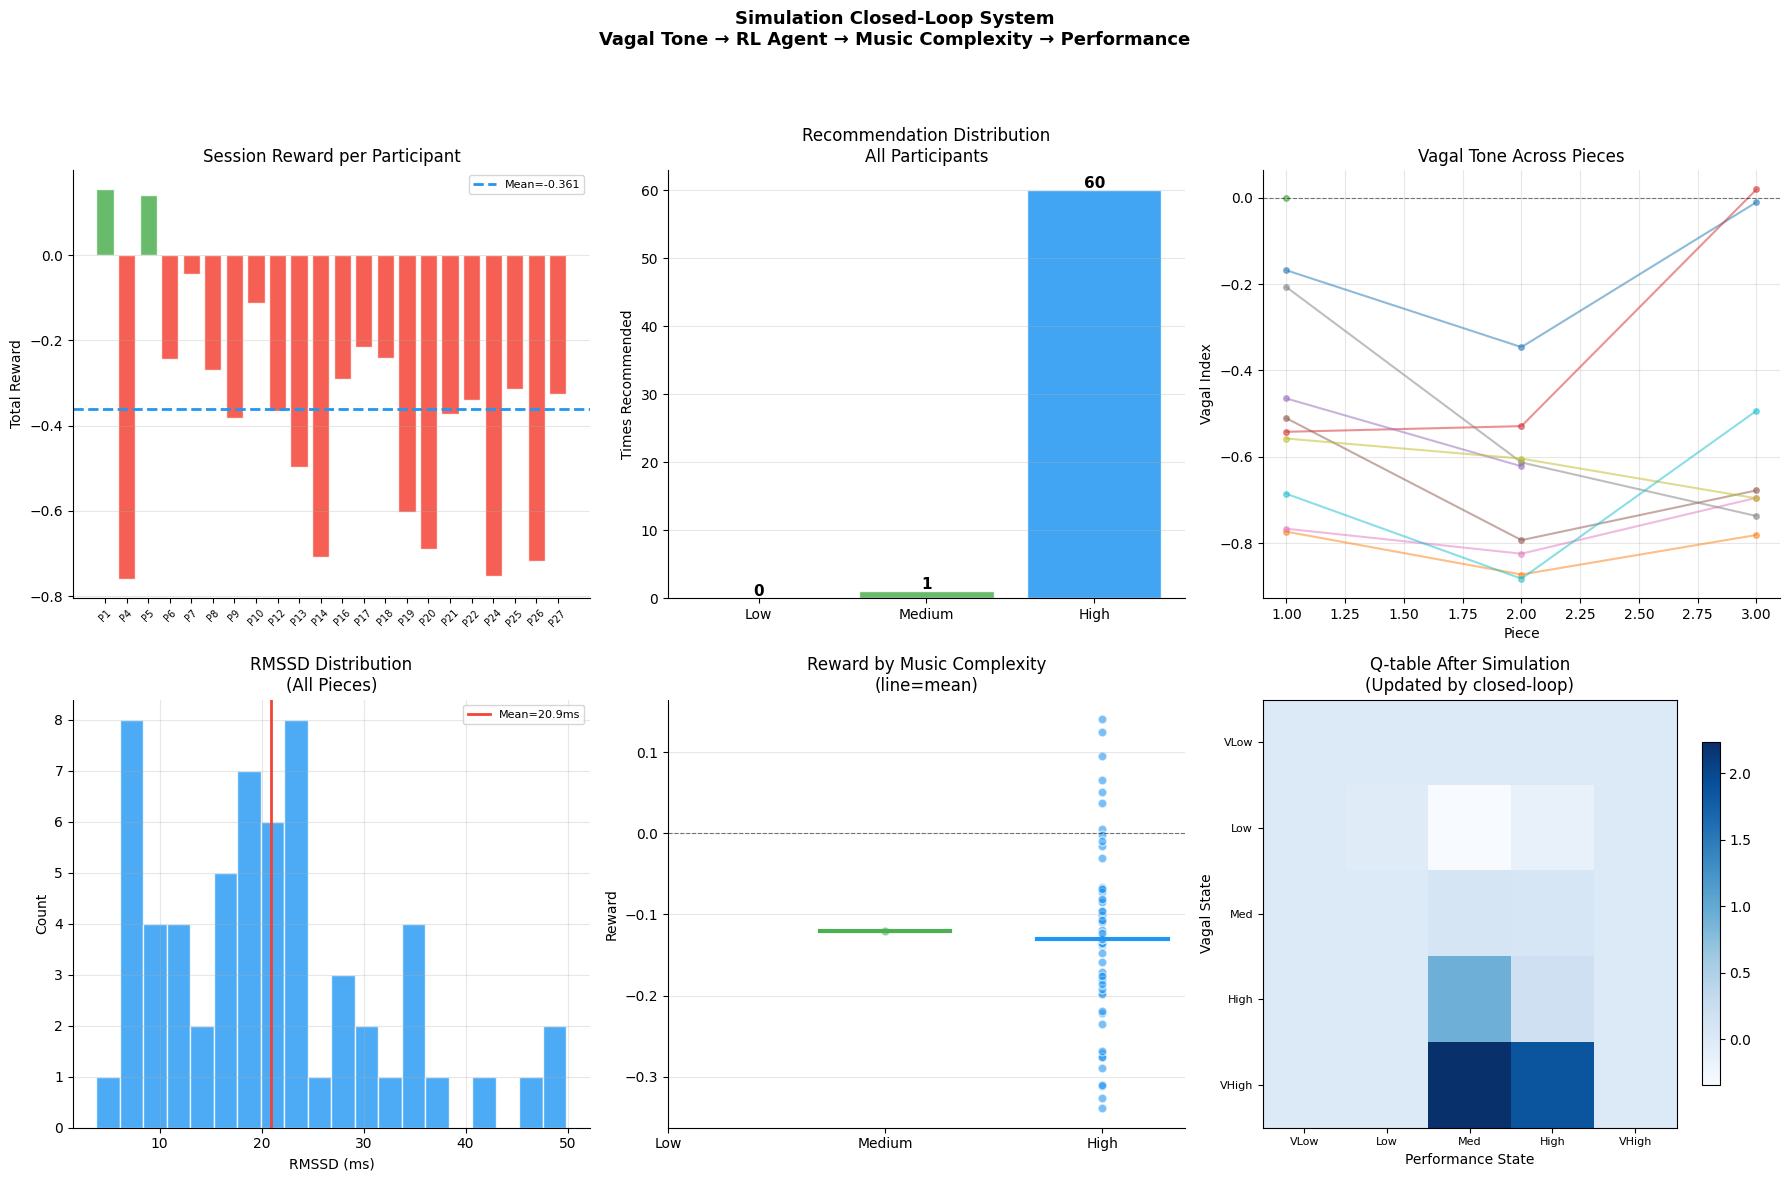

[PLOT] /Users/manognas/Downloads/2Inspire/Hexoskin/rsa_results/simulation_closed_loop.png

[SAVED] Q-table updated after simulation
[INFO] 22 participants | Mean reward=-0.361
[DONE]


In [3]:
"""
SIMULATION Closed-Loop System
Uses saved Hexoskin CSV files to simulate the closed-loop pipeline
Run this with your existing data
"""

import os, re, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

HEXOSKIN_DIR = '/Users/manognas/Downloads/2Inspire/Hexoskin'
OUTPUT_DIR   = os.path.join(HEXOSKIN_DIR, 'rsa_results')
N_BINS = 5
os.makedirs(OUTPUT_DIR, exist_ok=True)

CP = {
    'alpha_v':  0.8455, 'beta_v':  -0.0171,
    'theta':    0.0758,  'phi':     0.1849,
    'rho_p':   0.4048,  'k_hr':   -0.1363,
    'sigma_v':  0.10,   'sigma_p':  0.15,  'sigma_hr': 0.10,
}
COMPLEXITY    = {0:0.5, 1:2.5, 2:4.0}
ACTION_NAMES  = {0:'LOW (entropy<1.5)', 1:'MEDIUM (entropy 1.5-3.5)', 2:'HIGH (entropy>3.5)'}
ACTION_COLORS = {0:'#F44336', 1:'#4CAF50', 2:'#2196F3'}
def _style(ax): ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Load Q-table
q_path = os.path.join(OUTPUT_DIR,'q_table_updated.npy')
if not os.path.exists(q_path): q_path = os.path.join(OUTPUT_DIR,'q_table.npy')
Q = np.load(q_path) if os.path.exists(q_path) else np.zeros((N_BINS**2,3))
print(f"[OK] Q-table loaded")

def discretise(state):
    v  = float(np.clip(state[0],-2,2)); p = float(np.clip(state[3],-2,2))
    vb = max(0,min(int((v+2)/4*N_BINS),N_BINS-1))
    pb = max(0,min(int((p+2)/4*N_BINS),N_BINS-1))
    return vb*N_BINS+pb

def read_hex(path):
    try:
        df = pd.read_csv(path,header=None,skiprows=1)
        if df.empty or df.shape[1]<2: return pd.DataFrame(columns=['time','value'])
        df = df.iloc[:,:2].copy(); df.columns=['time','value']
        df['time']  = pd.to_numeric(df['time'], errors='coerce')
        df['value'] = pd.to_numeric(df['value'],errors='coerce')
        return df.dropna().reset_index(drop=True)
    except: return pd.DataFrame(columns=['time','value'])

def compute_rsa(folder_path):
    nn  = read_hex(os.path.join(folder_path,'NN_interval.csv'))
    br  = read_hex(os.path.join(folder_path,'breathing_rate.csv'))
    ins = read_hex(os.path.join(folder_path,'inspiration.csv'))
    if len(nn)<30: return None
    ibi   = nn['value'].values*1000
    valid = (ibi>=300)&(ibi<=2000)
    ibi   = ibi[valid]
    if len(ibi)<30: return None
    diffs = np.diff(ibi)
    rmssd = float(np.sqrt(np.mean(diffs**2)))
    pnn50 = float(np.mean(np.abs(diffs)>50))
    mean_hr = float(60000/np.mean(ibi))
    mean_br = float(br['value'].mean()) if len(br)>0 else 15.0
    vagal   = (rmssd-40)/20
    p2t_vals= []
    if len(ins)>=2:
        ins_t = ins['time'].values
        hr_t  = nn['time'].values[valid[:len(nn['time'])]]
        hr_v  = 60000/ibi
        for i in range(len(ins_t)-1):
            mask = (hr_t>=ins_t[i])&(hr_t<=ins_t[i+1])
            if mask.sum()>=2: p2t_vals.append(float(np.ptp(hr_v[mask])))
    if p2t_vals: vagal = (np.mean(p2t_vals)-10)/8
    return {'vagal_index':round(vagal,4),'rmssd':round(rmssd,2),
            'pnn50':round(pnn50,4),'mean_hr':round(mean_hr,1),
            'mean_br':round(mean_br,1),'n_beats':len(ibi),
            'quality':'good' if len(ibi)>=120 else 'marginal',
            'timestamp':datetime.now().strftime('%H:%M:%S')}

def transition(state, action):
    M=COMPLEXITY[action]; M_c=(M-2.5)/2.5
    V_t=state[0]; HR_t=state[1]; BR_t=state[2]; P_t=state[3]
    V_t1 =np.clip(CP['alpha_v']*V_t+CP['beta_v']*M_c+np.random.normal(0,CP['sigma_v']),-3,3)
    HR_t1=np.clip(HR_t+CP['k_hr']*(V_t1-V_t)+np.random.normal(0,CP['sigma_hr']),-3,3)
    BR_t1=np.clip(BR_t+0.05*M_c+np.random.normal(0,0.05),-3,3)
    P_t1 =np.clip(CP['rho_p']*P_t+CP['theta']*V_t1+CP['phi']*(M/4)+np.random.normal(0,CP['sigma_p']),-3,3)
    return np.array([V_t1,HR_t1,BR_t1,P_t1,V_t1*0.5,V_t1*0.3,state[6]+1],dtype=np.float32)

# Build participant mapping
map_rows=[]
for folder in sorted(os.listdir(HEXOSKIN_DIR)):
    if not folder.startswith('range_'): continue
    for item in os.listdir(os.path.join(HEXOSKIN_DIR,folder)):
        m=re.match(r'record_(\d+)',item)
        if m: map_rows.append({'range_folder':folder,'record_id':m.group(1)}); break
range_map = pd.DataFrame(map_rows)
record_ids= sorted(range_map['record_id'].unique())
AUDIO_DIR = os.path.join(os.path.dirname(HEXOSKIN_DIR),'audio')
if os.path.exists(AUDIO_DIR):
    p_nums = sorted(set(int(re.match(r'P(\d+)',f).group(1))
                        for f in os.listdir(AUDIO_DIR) if re.match(r'P(\d+)',f)))
    pid_map= dict(zip(record_ids,[str(p) for p in p_nums[:len(record_ids)]]))
else:
    pid_map= {r:r for r in record_ids}
range_map['p_number']=range_map['record_id'].map(pid_map)
range_map['piece']   =range_map.sort_values('range_folder')\
                               .groupby('record_id').cumcount()+1

# ── RUN SIMULATION ────────────────────────────────────────────────────────────

print("="*60)
print("  SIMULATION CLOSED-LOOP SYSTEM")
print("  Using saved Hexoskin CSV files")
print("="*60)

all_sessions=[]; Q_sim=Q.copy()

for rec_id,grp in range_map.groupby('record_id'):
    pid   = pid_map.get(rec_id,rec_id)
    pieces= grp[grp['piece']<=3].sort_values('piece')
    if len(pieces)==0: continue
    print(f"\n  ── P{pid} ──────────────────")
    state  = np.zeros(7,dtype=np.float32)
    session= {'pid':pid,'pieces':[]}

    for _,row in pieces.iterrows():
        fpath = os.path.join(HEXOSKIN_DIR,row['range_folder'])
        rsa   = compute_rsa(fpath)
        if rsa is None:
            print(f"    Piece {int(row['piece'])}: [SKIP] insufficient data"); continue

        # Update state from RSA
        prev  = state.copy()
        state = np.array([rsa['vagal_index'],
                          (rsa['mean_hr']-70)/20,
                          (rsa['mean_br']-15)/5,
                          state[3],
                          (rsa['rmssd']-40)/20,
                          rsa['pnn50'],
                          int(row['piece'])-1],dtype=np.float32)

        # Decide
        s_d    = discretise(state)
        action = int(np.argmax(Q_sim[s_d]))
        M      = COMPLEXITY[action]

        # Transition
        next_s = transition(state,action)

        # Reward
        reward = (0.40*np.tanh(next_s[0]) + 0.40*np.tanh(next_s[3]) +
                  0.10*np.tanh(next_s[0]-state[0]) -
                  0.15*max(0,next_s[1]-state[1]) +
                  0.05*(0.3 if 1.5<=M<=3.5 else -0.1))

        # Adapt
        ns_d = discretise(next_s)
        Q_sim[s_d,action] += 0.05*(reward+0.9*np.max(Q_sim[ns_d])-Q_sim[s_d,action])

        rationale = ("Low vagal — gentle complexity" if action==0 and state[0]<-0.5
                     else "Optimal zone — moderate complexity" if action==1
                     else "High vagal — push engagement" if action==2 and state[0]>0.5
                     else ACTION_NAMES[action])

        print(f"    Piece {int(row['piece'])}: "
              f"vagal={rsa['vagal_index']:+.3f} "
              f"RMSSD={rsa['rmssd']:.1f}ms "
              f"HR={rsa['mean_hr']:.0f}bpm → "
              f"RECOMMEND: {ACTION_NAMES[action]} | "
              f"reward={reward:+.3f}")
        print(f"             WHY: {rationale}")

        session['pieces'].append({'piece':int(row['piece']),'rsa':rsa,
                                  'action':action,'reward':reward,
                                  'next_state':next_s})
        state = next_s

    if session['pieces']:
        total_r = sum(p['reward'] for p in session['pieces'])
        session['total_reward'] = total_r
        all_sessions.append(session)
        print(f"    Session total reward: {total_r:+.3f}")

# ── PLOTS ──────────────────────────────────────────────────────────────────────

fig,axes = plt.subplots(2,3,figsize=(18,12))
fig.suptitle("Simulation Closed-Loop System\n"
             "Vagal Tone → RL Agent → Music Complexity → Performance",
             fontsize=13,fontweight='bold')

# 1. Reward per participant
ax=axes[0,0]
rewards=[s['total_reward'] for s in all_sessions]
pids   =[s['pid'] for s in all_sessions]
ax.bar(range(len(rewards)),rewards,
       color=['#4CAF50' if r>0 else '#F44336' for r in rewards],
       alpha=0.85,edgecolor='white')
ax.axhline(np.mean(rewards),color='#2196F3',lw=2,ls='--',
           label=f'Mean={np.mean(rewards):+.3f}')
ax.set_xticks(range(len(pids)))
ax.set_xticklabels([f"P{p}" for p in pids],fontsize=7,rotation=45)
ax.set(ylabel='Total Reward',title='Session Reward per Participant')
ax.legend(fontsize=8); ax.grid(axis='y',alpha=0.3); _style(ax)

# 2. Action distribution
ax=axes[0,1]
all_acts=[p['action'] for s in all_sessions for p in s['pieces']]
cnts=[all_acts.count(a) for a in [0,1,2]]
bars=ax.bar(['Low','Medium','High'],cnts,
            color=[ACTION_COLORS[i] for i in range(3)],alpha=0.85,edgecolor='white')
for b,v in zip(bars,cnts):
    ax.text(b.get_x()+b.get_width()/2,v+0.3,str(v),ha='center',fontsize=11,fontweight='bold')
ax.set(ylabel='Times Recommended',title='Recommendation Distribution\nAll Participants')
ax.grid(axis='y',alpha=0.3); _style(ax)

# 3. Vagal tone across pieces
ax=axes[0,2]
for sess in all_sessions[:10]:
    vagals=[p['rsa']['vagal_index'] for p in sess['pieces']]
    pieces=[p['piece'] for p in sess['pieces']]
    ax.plot(pieces,vagals,'o-',alpha=0.5,lw=1.5,ms=4)
ax.axhline(0,color='k',lw=0.8,ls='--',alpha=0.5)
ax.set(xlabel='Piece',ylabel='Vagal Index',title='Vagal Tone Across Pieces')
ax.grid(alpha=0.3); _style(ax)

# 4. RMSSD distribution
ax=axes[1,0]
all_rmssd=[p['rsa']['rmssd'] for s in all_sessions for p in s['pieces']]
ax.hist(all_rmssd,bins=20,color='#2196F3',alpha=0.8,edgecolor='white')
ax.axvline(np.mean(all_rmssd),color='#F44336',lw=2,
           label=f'Mean={np.mean(all_rmssd):.1f}ms')
ax.set(xlabel='RMSSD (ms)',ylabel='Count',title='RMSSD Distribution\n(All Pieces)')
ax.legend(fontsize=8); ax.grid(alpha=0.3); _style(ax)

# 5. Reward by action
ax=axes[1,1]
for a in [0,1,2]:
    r_vals=[p['reward'] for s in all_sessions
            for p in s['pieces'] if p['action']==a]
    if r_vals:
        ax.scatter([a]*len(r_vals),r_vals,
                   color=ACTION_COLORS[a],alpha=0.6,s=40,edgecolors='white')
        ax.plot([a-0.3,a+0.3],[np.mean(r_vals)]*2,
                color=ACTION_COLORS[a],lw=3)
ax.axhline(0,color='k',lw=0.8,ls='--',alpha=0.5)
ax.set_xticks([0,1,2]); ax.set_xticklabels(['Low','Medium','High'])
ax.set(ylabel='Reward',title='Reward by Music Complexity\n(line=mean)')
ax.grid(axis='y',alpha=0.3); _style(ax)

# 6. Q-table heatmap
ax=axes[1,2]
q_mat=np.max(Q_sim,axis=1).reshape(N_BINS,N_BINS)
im=ax.imshow(q_mat,cmap='Blues',aspect='auto')
ax.set_xticks(range(N_BINS))
ax.set_xticklabels(['VLow','Low','Med','High','VHigh'],fontsize=8)
ax.set_yticks(range(N_BINS))
ax.set_yticklabels(['VLow','Low','Med','High','VHigh'],fontsize=8)
ax.set(xlabel='Performance State',ylabel='Vagal State',
       title='Q-table After Simulation\n(Updated by closed-loop)')
plt.colorbar(im,ax=ax,shrink=0.8)

plt.tight_layout(rect=[0,0,1,.94])
path=os.path.join(OUTPUT_DIR,'simulation_closed_loop.png')
fig.savefig(path,dpi=150,bbox_inches='tight',facecolor='white')
plt.show(); plt.close(); print(f"[PLOT] {path}")

np.save(os.path.join(OUTPUT_DIR,'q_table_simulation.npy'),Q_sim)
print(f"\n[SAVED] Q-table updated after simulation")
print(f"[INFO] {len(all_sessions)} participants | Mean reward={np.mean(rewards):+.3f}")
print("[DONE]")